             ******** LIFE EXPECTANCY PREDICTION *******

In [5]:
# Standard library imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [18]:
# LOAD DATA

df = pd.read_csv("Life Expectancy Data.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("\nShape:", df.shape)


Shape: (2938, 22)


Life Expectancy dataset is a real-world, meaningful dataset that helps analyze how different health, economic, and social factors affect human life expectancy across countries.

In [19]:
# CHECK MISSING VALUES

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


We observe that some features like **Population, GDP, and Hepatitis B** have a high number of missing values, so proper imputation or handling is required before model building.

In [20]:
# BASIC STATISTICS

print("\nStatistical Summary:\n")

print(df.describe())



Statistical Summary:

              Year  Life expectancy  Adult Mortality  infant deaths  \
count  2938.000000      2928.000000      2928.000000    2938.000000   
mean   2007.518720        69.224932       164.796448      30.303948   
std       4.613841         9.523867       124.292079     117.926501   
min    2000.000000        36.300000         1.000000       0.000000   
25%    2004.000000        63.100000        74.000000       0.000000   
50%    2008.000000        72.100000       144.000000       3.000000   
75%    2012.000000        75.700000       228.000000      22.000000   
max    2015.000000        89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B        Measles  \
count  2744.000000             2938.000000  2385.000000    2938.000000   
mean      4.602861              738.251295    80.940461    2419.592240   
std       4.052413             1987.914858    25.070016   11467.272489   
min       0.010000                0.00000

- Life expectancy ranges from **36 to 89 years**, showing strong variation across countries.
- High standard deviation in **GDP, population, and mortality features** indicates large global differences.
- Many health indicators like **Hepatitis B and Alcohol consumption** vary significantly, affecting life expectancy.

In [21]:
# CHECK DUPLICATES

print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


There are **no duplicate values** in dataset.

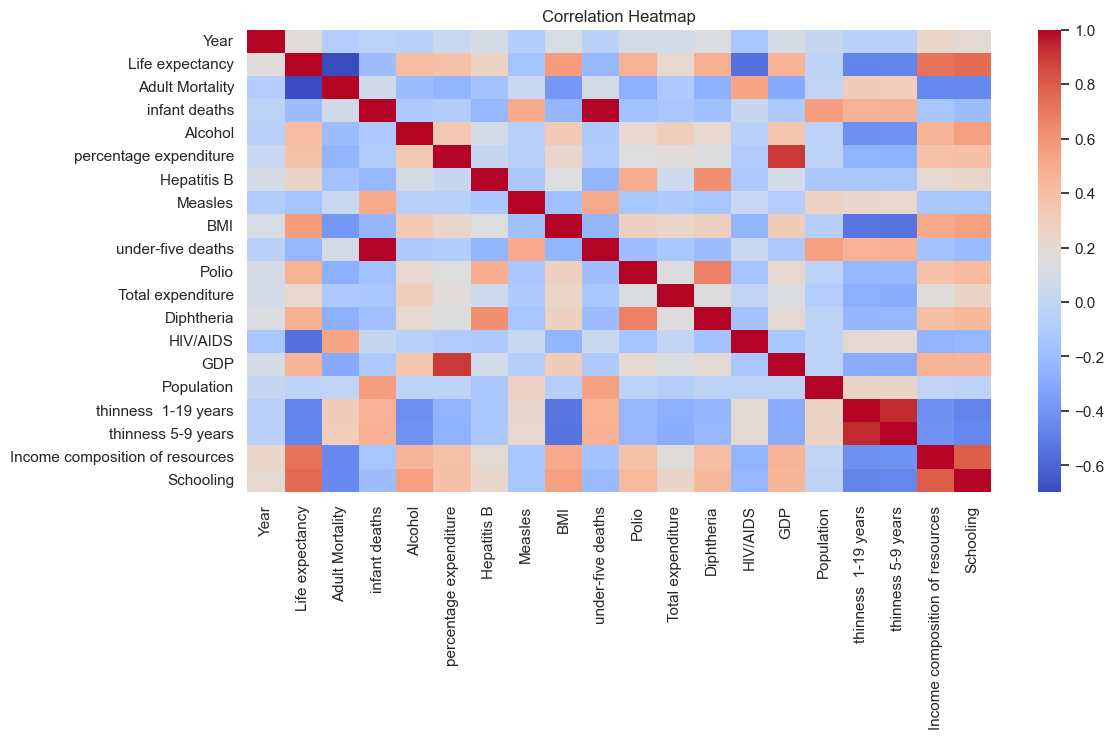

In [22]:
# CORRELATION HEATMAP

plt.figure(figsize=(12,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Life expectancy is strongly influenced by education, income, and healthcare access. Higher schooling and better income levels increase life expectancy, while high adult mortality and diseases like HIV/AIDS reduce it. Good nutrition and vaccination also improve overall health outcomes. Overall, countries with better socioeconomic and healthcare conditions tend to have higher life expectancy.

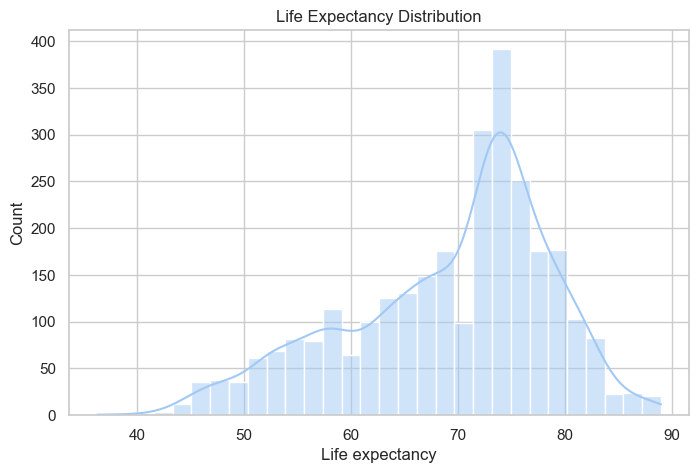

In [23]:
# LIFE EXPECTANCY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(df["Life expectancy"], kde=True)

plt.title("Life Expectancy Distribution")

plt.show()

The histogram shows the distribution of global life expectancy, ranging from about 40 to 90 years. Most values are concentrated between **70 and 80 years**, indicating that this is the most common life expectancy range in the dataset.

The distribution is **slightly left-skewed**, meaning fewer countries/regions have very low life expectancy, while most fall in the higher range. Overall, the chart highlights that globally, people tend to live longer in most regions, with only a small portion experiencing low life expectancy.

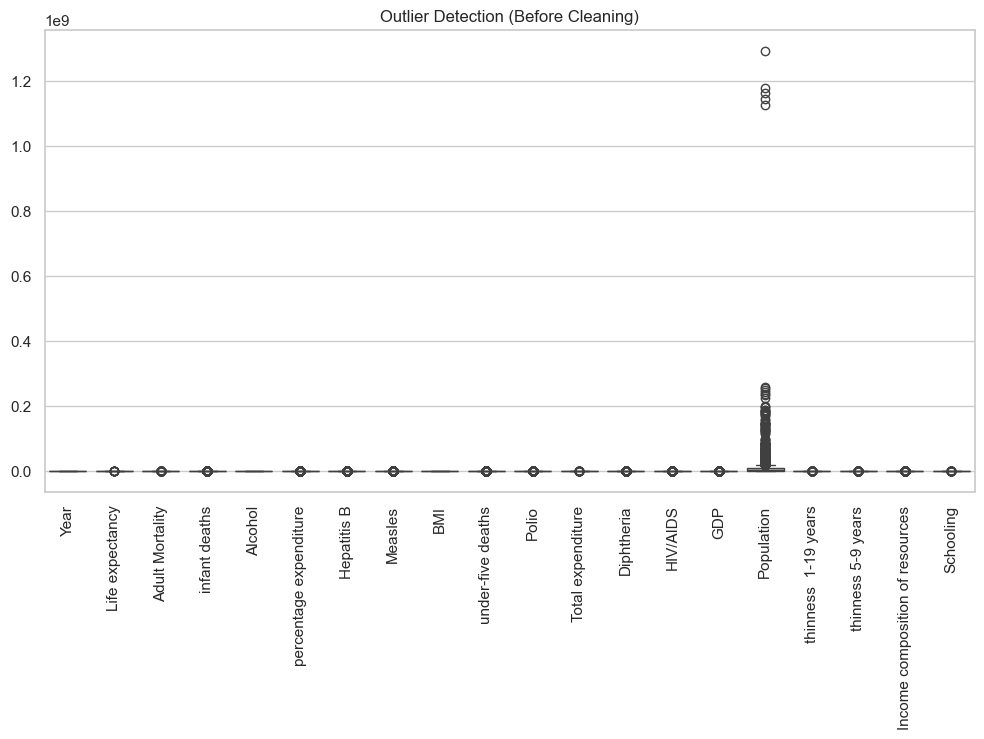

In [26]:
# OUTLIER VISUALIZATION

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df.select_dtypes(include=np.number),
    fill=True,
    color="skyblue"
)

plt.xticks(rotation=90)
plt.title("Outlier Detection (Before Cleaning)")
plt.show()

The boxplot shows the distribution of different numerical features before data cleaning. Most variables are fairly consistent, but some features contain significant outliers.

The **Population** column shows extremely large outliers compared to all other variables, indicating high variation across countries or possible data imbalance. Other features like GDP and mortality-related variables also show some spread, but not as extreme.

Overall, this visualization highlights the need for **outlier treatment and data normalization** before building a machine learning model.

In [63]:
#  REMOVE MISSING TARGET

df = df.dropna(subset=['Life expectancy'])

We removed rows where the target variable **Life expectancy** was missing, because the target column is essential for training a supervised machine learning model.

In [64]:
#  ENCODE + CLEAN DATA

le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

df = df.drop('Country', axis=1)


To prepare the dataset for machine learning, categorical variables were converted into numerical form.

In [65]:
# FEATURES & TARGET

X = df.drop('Life expectancy', axis=1)
y = df['Life expectancy']


The dataset is divided into input features and the target variable for machine learning.

In [66]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


The dataset is split into training and testing sets to evaluate the model’s performance on unseen data.

In [67]:
# HANDLE MISSING VALUES

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


Missing values in the dataset are handled using mean imputation to ensure the model receives complete data.

In [68]:
# MODEL FUNCTION

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("\n====================")
    print(name)
    print("====================")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return pred, mae, rmse, r2


A reusable function is created to train and evaluate different machine learning models using common performance metrics.

In [69]:
# TRAIN MODELS

lr_pred, lr_mae, lr_rmse, lr_r2 = evaluate(LinearRegression(), "Linear Regression")

dt_pred, dt_mae, dt_rmse, dt_r2 = evaluate(DecisionTreeRegressor(random_state=42), "Decision Tree")

rf_pred, rf_mae, rf_rmse, rf_r2 = evaluate(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest")


Linear Regression
MAE : 4.288998785822712
RMSE: 6.084098214988416
R2  : 0.5720635045368583

Decision Tree
MAE : 1.4918088737201363
RMSE: 2.5654703711514526
R2  : 0.9239111710771895

Random Forest
MAE : 1.0540307167235514
RMSE: 1.663637889477081
R2  : 0.9680033508557784


Multiple machine learning models are trained and evaluated to compare their performance in predicting life expectancy.

In [70]:
# MODEL COMPARISON

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

print("\nMODEL COMPARISON:\n", results)



MODEL COMPARISON:
                Model       MAE      RMSE  R2 Score
0  Linear Regression  4.288999  6.084098  0.572064
1      Decision Tree  1.491809  2.565470  0.923911
2      Random Forest  1.054031  1.663638  0.968003


The performance of different regression models was evaluated using MAE, RMSE, and R² Score.
The **Random Forest Regressor** performed the best with the highest R² score (0.968) and the lowest error values.
Ensemble methods like Random Forest outperform simpler models because they reduce overfitting and improve prediction accuracy by combining multiple decision trees.

In [71]:
# FEATURE IMPORTANCE

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTOP FEATURES:\n", feature_importance.head(10))



TOP FEATURES:
                             Feature  Importance
13                         HIV/AIDS    0.595765
18  Income composition of resources    0.155867
2                   Adult Mortality    0.135127
19                        Schooling    0.021455
9                 under-five deaths    0.015177
8                               BMI    0.014718
17               thinness 5-9 years    0.008997
4                           Alcohol    0.007492
0                              Year    0.007385
16             thinness  1-19 years    0.006194


- **HIV/AIDS** is the most influential factor affecting life expectancy.
- Socioeconomic factors like **income composition and schooling** also play a major role.
- Health and mortality indicators significantly impact the prediction outcome.

- This shows that both **health conditions and socioeconomic development** are critical in determining life expectancy.

In [72]:
# OUTLIER DETECTION (IQR METHOD)

def detect_outliers(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    outlier_counts = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        outlier_counts[col] = count

    return outlier_counts

print("\nOUTLIER COUNT PER COLUMN:")
print(detect_outliers(df))




OUTLIER COUNT PER COLUMN:
{'Year': 0, 'Status': 512, 'Life expectancy': 10, 'Adult Mortality': 82, 'infant deaths': 315, 'Alcohol': 0, 'percentage expenditure': 388, 'Hepatitis B': 252, 'Measles': 542, 'BMI': 0, 'under-five deaths': 394, 'Polio': 278, 'Total expenditure': 30, 'Diphtheria': 297, 'HIV/AIDS': 542, 'GDP': 363, 'Population': 294, 'thinness  1-19 years': 89, 'thinness 5-9 years': 97, 'Income composition of resources': 130, 'Schooling': 42}


Several features such as **Measles, HIV/AIDS, GDP, and Infant Deaths** contain a high number of outliers, indicating strong variability in global health and economic conditions.
Outlier treatment or robust models like **Random Forest** are important to ensure stable and accurate predictions.

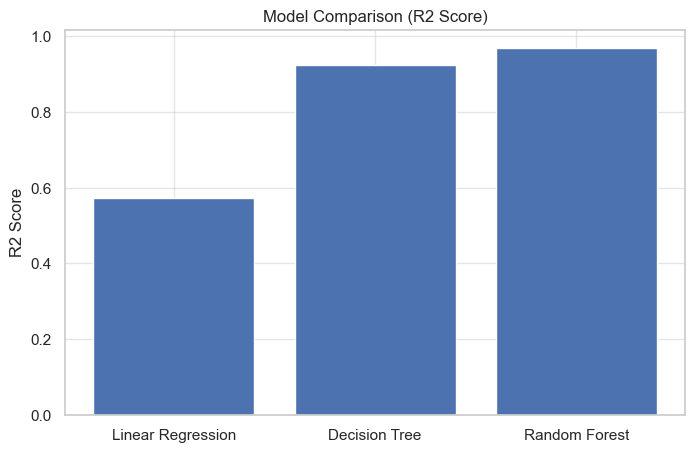

In [73]:
# VISUALIZATION - MODEL PERFORMANCE

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

The bar chart compares the performance of three machine learning models based on their R² scores.

Linear Regression shows the lowest performance with an R² score of around 0.57, indicating limited ability to capture complex patterns in the data. In contrast, the Decision Tree model performs significantly better with a score above 0.92, showing strong improvement in capturing non-linear relationships.

The Random Forest model achieves the best performance with an R² score close to 0.97, making it the most accurate and reliable model among the three.

Tree-based and ensemble methods clearly outperform Linear Regression for this dataset, suggesting that the relationship between features and life expectancy is highly non-linear.

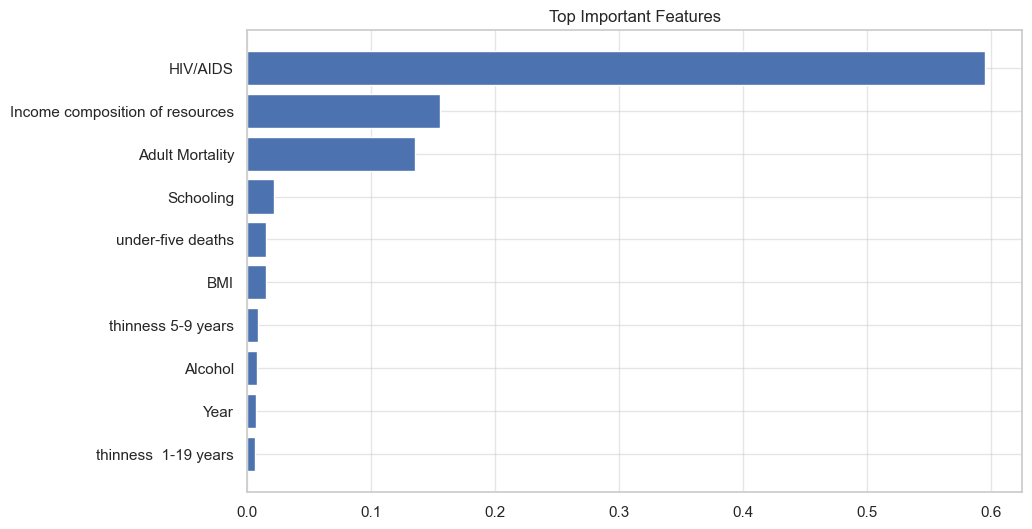

In [74]:
# VISUALIZATION - FEATURE IMPORTANCE

plt.figure(figsize=(10,6))
top = feature_importance.head(10)

plt.barh(top["Feature"], top["Importance"])
plt.title("Top Important Features")
plt.gca().invert_yaxis()
plt.show()


The horizontal bar chart shows the ranking of features based on their importance in the prediction model.

HIV/AIDS is the most influential factor by a large margin, indicating it has the strongest impact on life expectancy predictions. Economic and social indicators such as income composition and adult mortality also play a major role, acting as strong secondary predictors.

Education-related factors like schooling and child health indicators (infant and under-five deaths) contribute moderately to the model. In contrast, features such as alcohol consumption and BMI have relatively low importance in predicting outcomes.

Overall, the model shows that **health-related diseases and economic conditions are the dominant factors**, while lifestyle and minor health indicators have less influence on life expectancy.

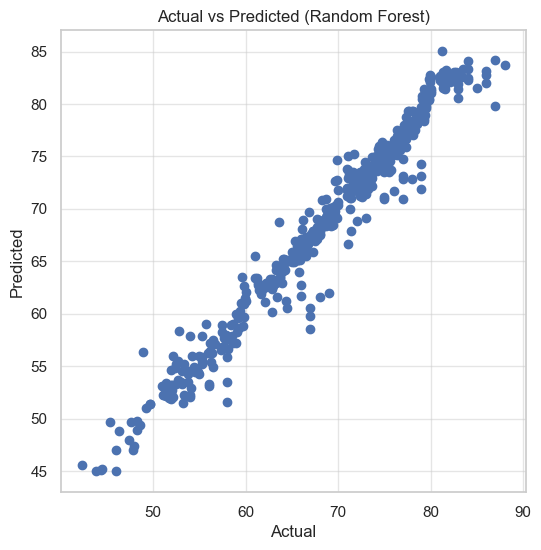

In [75]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

The scatter plot compares actual values with predicted values generated by the Random Forest model.

Most data points are closely aligned along the diagonal line, indicating that the model predictions are very close to the actual values. This strong clustering demonstrates high predictive accuracy and a strong correlation between predicted and real outcomes.

A few outliers are present where predictions deviate from actual values, but these are minimal and do not significantly affect overall performance. The majority of values lie between the 45 to 85 range, reflecting the distribution of life expectancy in the dataset.

The Random Forest model shows strong performance and reliability, with predictions closely matching actual values, making it the best-performing model for this dataset.

In [76]:
## SAVE MODEL

joblib.dump(rf_model, "life_expectancy_model.pkl")

print("\nMODEL SAVED SUCCESSFULLY ✔")


MODEL SAVED SUCCESSFULLY ✔


The best-performing model (Random Forest) is saved so it can be reused for future predictions without retraining.